Fish image classification using Deep learning

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2, InceptionV3, EfficientNetB0
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
TRAIN_PATH = r"C:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Fish_image_classifcation\Dataset\images.cv_jzk6llhf18tm3k0kyttxz\data\train" 
VAL_PATH = r"C:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Fish_image_classifcation\Dataset\images.cv_jzk6llhf18tm3k0kyttxz\data\val" 
IMG_SIZE = (224,224) 
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)


NUM_CLASSES = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())

print("Classes:", train_generator.class_indices)
print("Class Names:", class_names)

Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Classes: {'animal fish': 0, 'animal fish bass': 1, 'fish sea_food black_sea_sprat': 2, 'fish sea_food gilt_head_bream': 3, 'fish sea_food hourse_mackerel': 4, 'fish sea_food red_mullet': 5, 'fish sea_food red_sea_bream': 6, 'fish sea_food sea_bass': 7, 'fish sea_food shrimp': 8, 'fish sea_food striped_red_mullet': 9, 'fish sea_food trout': 10}
Class Names: ['animal fish', 'animal fish bass', 'fish sea_food black_sea_sprat', 'fish sea_food gilt_head_bream', 'fish sea_food hourse_mackerel', 'fish sea_food red_mullet', 'fish sea_food red_sea_bream', 'fish sea_food sea_bass', 'fish sea_food shrimp', 'fish sea_food striped_red_mullet', 'fish sea_food trout']


In [3]:
def build_cnn(input_shape, num_classes):

    model = Sequential([
        Conv2D(32,(3,3),activation='relu',input_shape=input_shape),
        MaxPooling2D(2,2),

        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128,(3,3),activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(256,activation='relu'),
        Dropout(0.5),
        Dense(num_classes,activation='softmax')
    ])

    return model

In [4]:
def build_cnn():
    model = Sequential([
        Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
        MaxPooling2D(2,2),

        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128,(3,3),activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(256,activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES,activation='softmax')
    ])
    return model

In [5]:
cnn_model = build_cnn()

cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 142s 724ms/step - accuracy: 0.4198 - loss: 1.6681 - val_accuracy: 0.6310 - val_loss: 1.0395
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 145s 740ms/step - accuracy: 0.6408 - loss: 1.0118 - val_accuracy: 0.7179 - val_loss: 0.7382
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 245s 1s/step - accuracy: 0.7492 - loss: 0.7290 - val_accuracy: 0.8516 - val_loss: 0.4826
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 123s 616ms/step - accuracy: 0.8077 - loss: 0.5709 - val_accuracy: 0.9029 - val_loss: 0.3290
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 109s 559ms/step - accuracy: 0.8439 - loss: 0.4493 - val_accuracy: 0.9038 - val_loss: 0.3221
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 142s 726ms/step - accuracy: 0.8668 - loss: 0.3881 - val_accuracy: 0.9396 - val_loss: 0.2230
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 110s 561ms/step - accuracy: 0.8949 - loss: 0.3172 - val_accuracy: 0.9386 - val_loss: 0.2127
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 118s 602ms/step - accuracy: 0.8996 - lo

In [6]:
def build_model(base_model):

    base_model.trainable = False  # freeze pretrained layers

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [7]:
from tensorflow.keras.applications import VGG16

base = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
model_vgg16 = build_model(base)

history_vgg16 = model_vgg16.fit(train_generator, validation_data=val_generator, epochs=10)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 347s 2s/step - accuracy: 0.4522 - loss: 1.6643 - val_accuracy: 0.7390 - val_loss: 1.0920
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 337s 2s/step - accuracy: 0.7128 - loss: 0.9553 - val_accuracy: 0.8507 - val_loss: 0.6554
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 341s 2s/step - accuracy: 0.7944 - loss: 0.6838 - val_accuracy: 0.8782 - val_loss: 0.4871
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 339s 2s/step - accuracy: 0.8376 - loss: 0.5455 - val_accuracy: 0.9084 - val_loss: 0.3867
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 335s 2s/step - accuracy: 0.8683 - loss: 0.4398 - val_accuracy: 0.9341 - val_loss: 0.2840
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 336s 2s/step - accuracy: 0.8805 - loss: 0.3883 - val_accuracy: 0.9405 - val_loss: 0.2427
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 336s 2s/step - accuracy: 0.8924 - loss: 0.3523 - val_accuracy: 0.9405 - val_loss: 0.2454
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 335s 2s/step - accuracy: 0.9092 - loss: 0.3080 - val_accu

In [8]:
from tensorflow.keras.applications import ResNet50

base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
model_resnet = build_model(base)

history_resnet = model_resnet.fit(train_generator, validation_data=val_generator, epochs=10)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 150s 737ms/step - accuracy: 0.1608 - loss: 2.3210 - val_accuracy: 0.1676 - val_loss: 2.2251
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 143s 734ms/step - accuracy: 0.1910 - loss: 2.2157 - val_accuracy: 0.2308 - val_loss: 2.1588
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 142s 727ms/step - accuracy: 0.2064 - loss: 2.1574 - val_accuracy: 0.1951 - val_loss: 2.1053
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 144s 736ms/step - accuracy: 0.2161 - loss: 2.1245 - val_accuracy: 0.2134 - val_loss: 2.0581
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 266s 1s/step - accuracy: 0.2247 - loss: 2.0980 - val_accuracy: 0.2372 - val_loss: 2.0274
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 436s 2s/step - accuracy: 0.2426 - loss: 2.0682 - val_accuracy: 0.3141 - val_loss: 1.9961
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 142s 729ms/step - accuracy: 0.2453 - loss: 2.0378 - val_accuracy: 0.3132 - val_loss: 1.9499
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 138s 709ms/step - accuracy: 0.2582 - loss:

In [9]:
from tensorflow.keras.applications import MobileNet

base = MobileNet(weights='imagenet', include_top=False, input_shape=(224,224,3))
model_mobilenet = build_model(base)

history_mobilenet = model_mobilenet.fit(train_generator, validation_data=val_generator, epochs=10)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 75s 375ms/step - accuracy: 0.8315 - loss: 0.5432 - val_accuracy: 0.9808 - val_loss: 0.1010
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 69s 352ms/step - accuracy: 0.9502 - loss: 0.1569 - val_accuracy: 0.9899 - val_loss: 0.0388
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 69s 351ms/step - accuracy: 0.9680 - loss: 0.1028 - val_accuracy: 0.9936 - val_loss: 0.0255
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 68s 350ms/step - accuracy: 0.9761 - loss: 0.0724 - val_accuracy: 0.9908 - val_loss: 0.0325
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 68s 351ms/step - accuracy: 0.9764 - loss: 0.0680 - val_accuracy: 0.9963 - val_loss: 0.0150
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 67s 346ms/step - accuracy: 0.9835 - loss: 0.0516 - val_accuracy: 0.9936 - val_loss: 0.0154
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 69s 352ms/step - accuracy: 0.9860 - loss: 0.0465 - val_accuracy: 0.9963 - val_loss: 0.0105
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 69s 353ms/step - accuracy: 0.9814 - loss: 0

In [10]:
from tensorflow.keras.applications import InceptionV3

base = InceptionV3(weights='imagenet', include_top=False, input_shape=(224,224,3))
model_inception = build_model(base)

history_inception = model_inception.fit(train_generator, validation_data=val_generator, epochs=10)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 104s 500ms/step - accuracy: 0.7534 - loss: 0.7568 - val_accuracy: 0.9377 - val_loss: 0.2321
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 93s 474ms/step - accuracy: 0.8959 - loss: 0.3207 - val_accuracy: 0.9615 - val_loss: 0.1325
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 95s 487ms/step - accuracy: 0.9118 - loss: 0.2714 - val_accuracy: 0.9707 - val_loss: 0.1052
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 92s 473ms/step - accuracy: 0.9216 - loss: 0.2264 - val_accuracy: 0.9698 - val_loss: 0.0943
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 94s 481ms/step - accuracy: 0.9320 - loss: 0.2012 - val_accuracy: 0.9597 - val_loss: 0.1069
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 94s 479ms/step - accuracy: 0.9346 - loss: 0.1975 - val_accuracy: 0.9670 - val_loss: 0.1004
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 93s 476ms/step - accuracy: 0.9412 - loss: 0.1708 - val_accuracy: 0.9817 - val_loss: 0.0653
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 93s 478ms/step - accuracy: 0.9438 - loss: 

In [11]:
from tensorflow.keras.applications import EfficientNetB0

base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
model_efficient = build_model(base)

history_efficient = model_efficient.fit(train_generator, validation_data=val_generator, epochs=10)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 90s 423ms/step - accuracy: 0.1547 - loss: 2.3401 - val_accuracy: 0.1712 - val_loss: 2.3144
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 80s 408ms/step - accuracy: 0.1735 - loss: 2.3128 - val_accuracy: 0.1712 - val_loss: 2.3111
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 87s 447ms/step - accuracy: 0.1761 - loss: 2.3100 - val_accuracy: 0.1712 - val_loss: 2.3089
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 83s 427ms/step - accuracy: 0.1761 - loss: 2.3090 - val_accuracy: 0.1712 - val_loss: 2.3137
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 83s 425ms/step - accuracy: 0.1761 - loss: 2.3076 - val_accuracy: 0.1712 - val_loss: 2.3155
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 83s 426ms/step - accuracy: 0.1761 - loss: 2.3055 - val_accuracy: 0.1712 - val_loss: 2.3112
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 83s 424ms/step - accuracy: 0.1761 - loss: 2.3035 - val_accuracy: 0.1712 - val_loss: 2.3102
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 82s 420ms/step - accuracy: 0.1761 - loss: 2

In [12]:
best_acc = 0
best_model = None

models = {
    "VGG16": model_vgg16,
    "ResNet": model_resnet,
    "MobileNet": model_mobilenet,
    "Inception": model_inception,
    "EfficientNet": model_efficient
}

for name, model in models.items():
    loss, acc = model.evaluate(val_generator)
    print(name, acc)

    if acc > best_acc:
        best_acc = acc
        best_model = model

best_model.save("best_overall_model.h5")

35/35 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.9606 - loss: 0.1554
VGG16 0.9606227278709412
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 576ms/step - accuracy: 0.3278 - loss: 1.9204
ResNet 0.32783883810043335
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - accuracy: 0.9936 - loss: 0.0204
MobileNet 0.9935897588729858
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 337ms/step - accuracy: 0.9762 - loss: 0.0756
Inception 0.976190447807312
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 235ms/step - accuracy: 0.1712 - loss: 2.3113


EfficientNet 0.17124542593955994


In [13]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

results = {}

for name, model in models.items():
    print(f"\nEvaluating {name}...")

    # Accuracy
    loss, acc = model.evaluate(val_generator)
    
    # Predictions
    y_pred = model.predict(val_generator)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = val_generator.classes

    # Classification report
    report = classification_report(y_true, y_pred_classes, output_dict=True)

    # Store metrics
    results[name] = {
        "accuracy": acc,
        "precision": report['weighted avg']['precision'],
        "recall": report['weighted avg']['recall'],
        "f1_score": report['weighted avg']['f1-score'],
        "confusion_matrix": confusion_matrix(y_true, y_pred_classes)
    }

    print(f"{name} Accuracy: {acc:.4f}")


Evaluating VGG16...
35/35 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.9606 - loss: 0.1554
35/35 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step
VGG16 Accuracy: 0.9606

Evaluating ResNet...


c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 576ms/step - accuracy: 0.3278 - loss: 1.9204
35/35 ━━━━━━━━━━━━━━━━━━━━ 23s 615ms/step
ResNet Accuracy: 0.3278

Evaluating MobileNet...


c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - accuracy: 0.9936 - loss: 0.0204
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 178ms/step
MobileNet Accuracy: 0.9936

Evaluating Inception...
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 339ms/step - accuracy: 0.9762 - loss: 0.0756
35/35 ━━━━━━━━━━━━━━━━━━━━ 15s 387ms/step
Inception Accuracy: 0.9762

Evaluating EfficientNet...


c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 236ms/step - accuracy: 0.1712 - loss: 2.3113
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 281ms/step
EfficientNet Accuracy: 0.1712


c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [14]:
for name, metrics in results.items():
    print(f"\n{name}")
    print(f"Accuracy  : {metrics['accuracy']:.4f}")
    print(f"Precision : {metrics['precision']:.4f}")
    print(f"Recall    : {metrics['recall']:.4f}")
    print(f"F1 Score  : {metrics['f1_score']:.4f}")


VGG16
Accuracy  : 0.9606
Precision : 0.1120
Recall    : 0.1136
F1 Score  : 0.1127

ResNet
Accuracy  : 0.3278
Precision : 0.0851
Recall    : 0.1136
F1 Score  : 0.0839

MobileNet
Accuracy  : 0.9936
Precision : 0.1136
Recall    : 0.1145
F1 Score  : 0.1140

Inception
Accuracy  : 0.9762
Precision : 0.0977
Recall    : 0.0989
F1 Score  : 0.0982

EfficientNet
Accuracy  : 0.1712
Precision : 0.0293
Recall    : 0.1712
F1 Score  : 0.0501


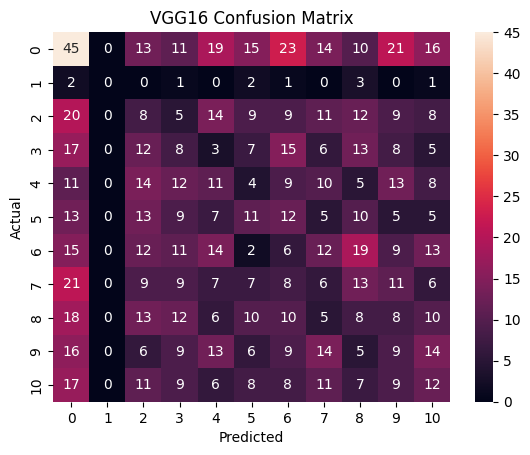

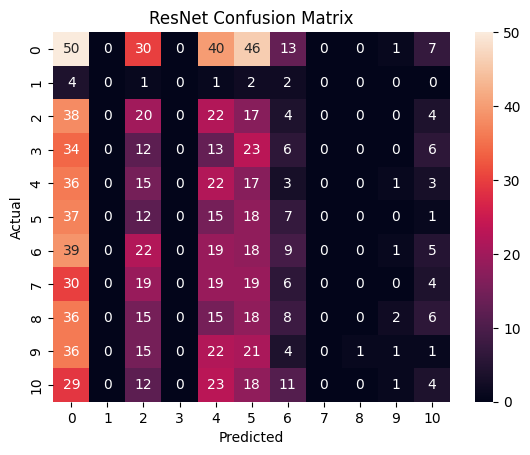

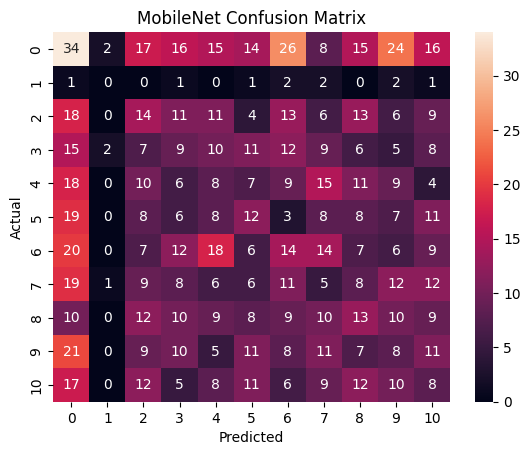

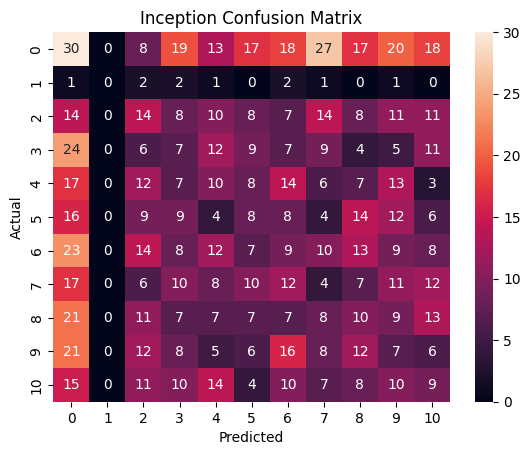

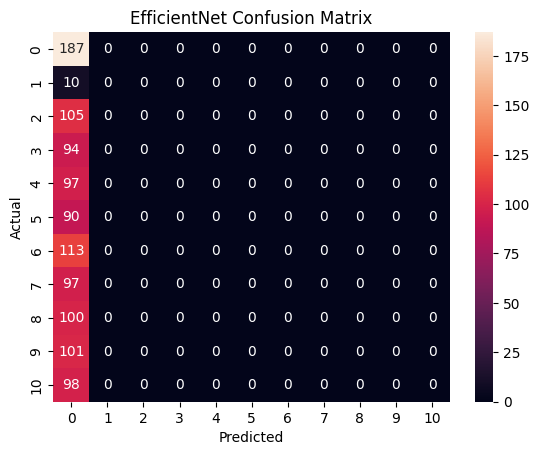

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

for name, metrics in results.items():
    plt.figure()
    sns.heatmap(metrics["confusion_matrix"], annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

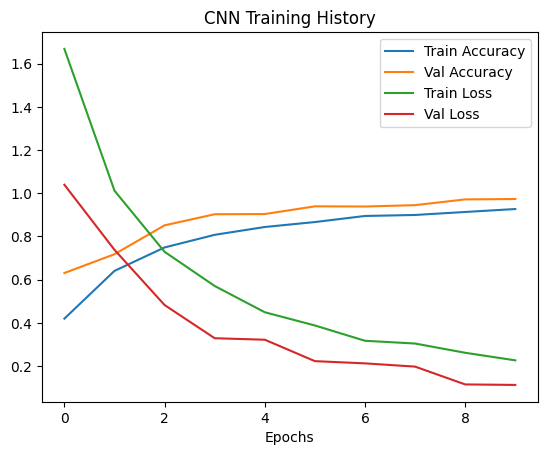

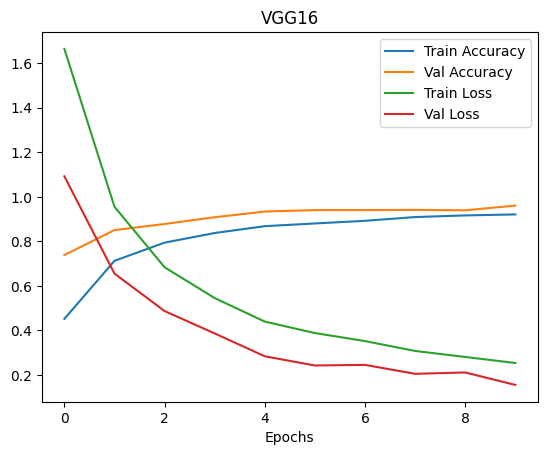

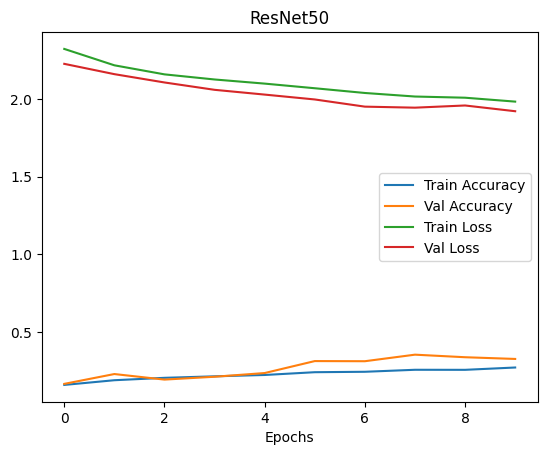

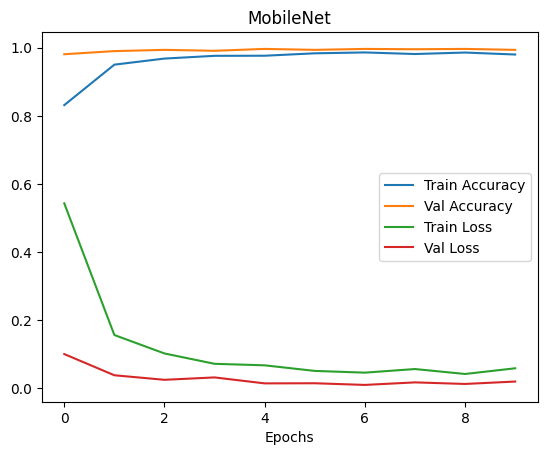

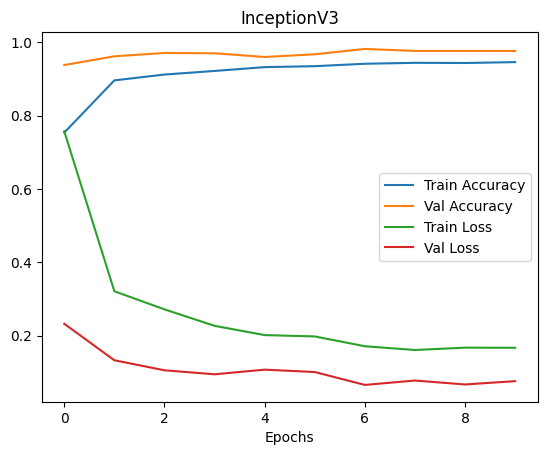

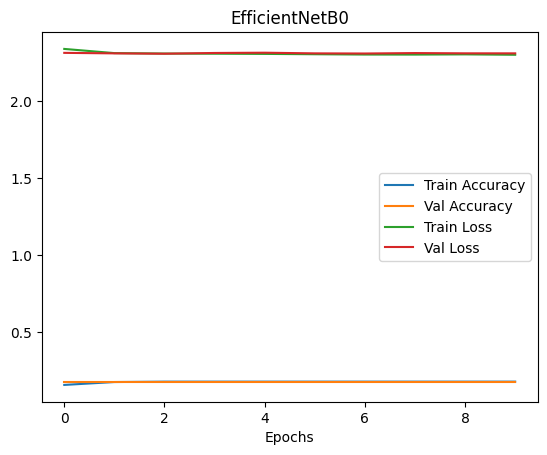

In [16]:
def plot_history(history, title):
    plt.figure()

    # Accuracy
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')

    # Loss
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')

    plt.title(title)
    plt.xlabel("Epochs")
    plt.legend()
    plt.show()


plot_history(history_cnn, "CNN Training History")
plot_history(history_vgg16, "VGG16")
plot_history(history_resnet, "ResNet50")
plot_history(history_mobilenet, "MobileNet")
plot_history(history_inception, "InceptionV3")
plot_history(history_efficient, "EfficientNetB0")